We are importing all the required libraries for the project.



In [1]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

In [5]:
# Read data
df = pd.read_csv("winequality-white.csv", delimiter=';')
df_red = pd.read_csv("winequality-red.csv", delimiter=';')
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6


### Data pre-processing


In [6]:
# Data pre-processing
#white wine
scaler = StandardScaler()

data_scaled = scaler.fit_transform(df)

df_scaled = pd.DataFrame(data_scaled, columns=df.columns)

df_scaled = pd.DataFrame(data_scaled, columns=df.columns) # Covert NumPy array to Dataframe

#red wine
scaler = StandardScaler()
data_scaled_red = scaler.fit_transform(df_red)


df_scaled.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,0.172097,-0.081770,0.213280,2.821349,-0.035355,0.569932,0.744565,2.331512,-1.246921,-0.349184,-1.393152,0.13787
1,-0.657501,0.215896,0.048001,-0.944765,0.147747,-1.253019,-0.149685,-0.009154,0.740029,0.001342,-0.824276,0.13787
2,1.475751,0.017452,0.543838,0.100282,0.193523,-0.312141,-0.973336,0.358665,0.475102,-0.436816,-0.336667,0.13787
3,0.409125,-0.478657,-0.117278,0.415768,0.559727,0.687541,1.121091,0.525855,0.011480,-0.787342,-0.499203,0.13787
4,0.409125,-0.478657,-0.117278,0.415768,0.559727,0.687541,1.121091,0.525855,0.011480,-0.787342,-0.499203,0.13787


Scaling the data using StandardScaler so that all features are on the same scale.
This is important because clustering algorithms like K-Means depend on distance, and features with larger values can dominate the results.

### Apply K-Means and Hierarchical (agglomerative) Clustering


In [7]:
# --- K-Means Clustering (White Wine) ---

# choosing number of clusters
k = 3

# creating and fitting model
kmeans = KMeans(n_clusters=k, random_state=42)
kmeans_labels = kmeans.fit_predict(data_scaled)

# adding cluster labels to dataframe
df_white = df.copy()
df_white["KMeans_Cluster"] = kmeans_labels

# check
df_white.head()


# --- K-Means Clustering (Red Wine) ---

# assuming you already loaded df_red and scaled it as data_scaled_red

kmeans = KMeans(n_clusters=k, random_state=42)
kmeans_labels_red = kmeans.fit_predict(data_scaled_red)

df_red["KMeans_Cluster"] = kmeans_labels_red

# check
df_red.head()



,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,KMeans_Cluster
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,0
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,0
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,2
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0


In [8]:
# Hierarchical_clustering (white wine)
agglo = AgglomerativeClustering(n_clusters=3)
agglo_labels = agglo.fit_predict(data_scaled)

df_white = df.copy()
df_white["Hierarchical_Cluster"] = agglo_labels

df_white.head()


# Hierarchical_clustering (red wine)
agglo = AgglomerativeClustering(n_clusters=3)
agglo_labels_red = agglo.fit_predict(data_scaled_red)

df_red["Hierarchical_Cluster"] = agglo_labels_red

df_red.head()



,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,KMeans_Cluster,Hierarchical_Cluster
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0,1
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,0,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,0,1
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,2,1
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0,1


### Visualizing Clusters: KMeans



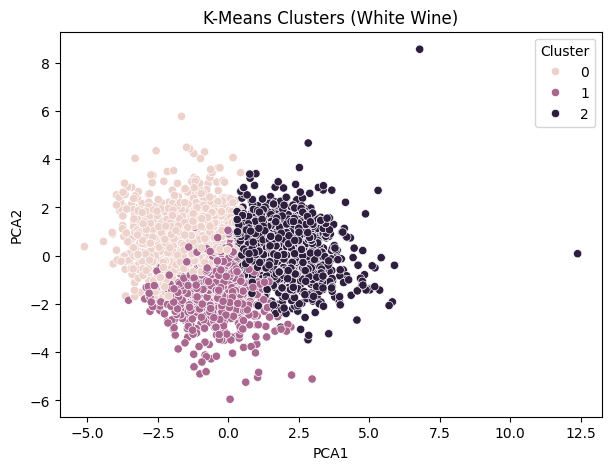

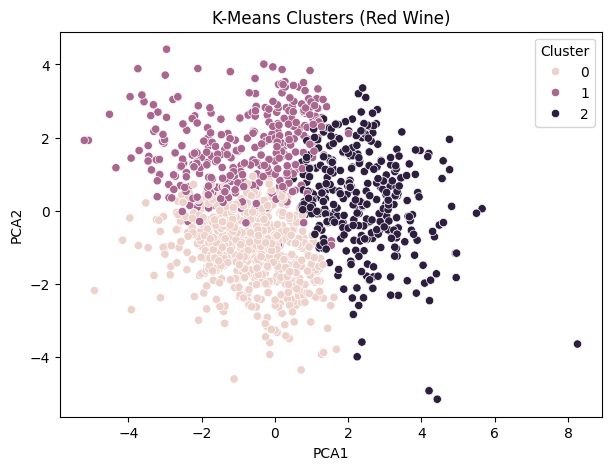

In [9]:
# white wine
pca = PCA(n_components=2)
pca_data = pca.fit_transform(data_scaled)

df_pca = pd.DataFrame(pca_data, columns=["PCA1", "PCA2"])
df_pca["Cluster"] = kmeans_labels

plt.figure(figsize=(7, 5))
sns.scatterplot(data=df_pca, x="PCA1", y="PCA2", hue="Cluster")
plt.title("K-Means Clusters (White Wine)")
plt.show()


# red wine
pca = PCA(n_components=2)
pca_data_red = pca.fit_transform(data_scaled_red)

df_pca_red = pd.DataFrame(pca_data_red, columns=["PCA1", "PCA2"])
df_pca_red["Cluster"] = kmeans_labels_red

plt.figure(figsize=(7, 5))
sns.scatterplot(data=df_pca_red, x="PCA1", y="PCA2", hue="Cluster")
plt.title("K-Means Clusters (Red Wine)")
plt.show()

### Optimal _k_


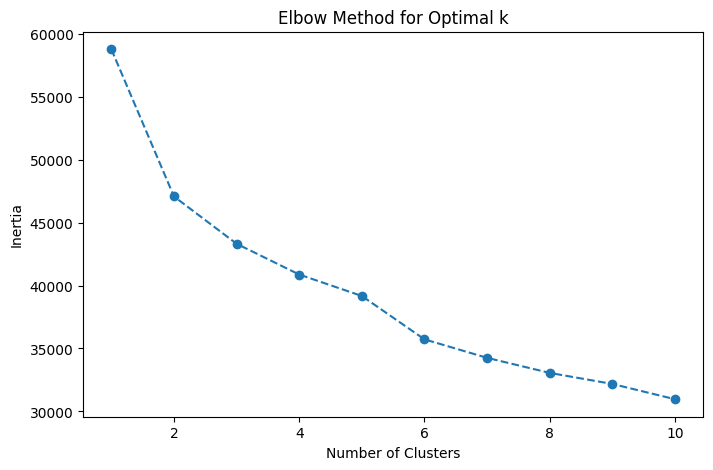

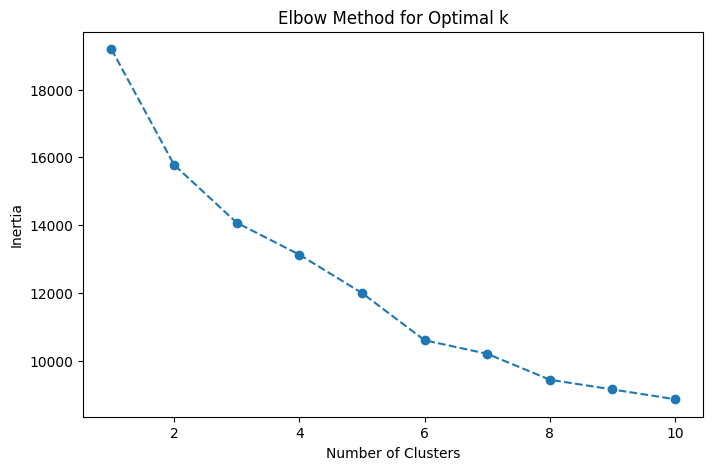

In [11]:
# Finding optimal k using Elbow Method
#white wine
inertia = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(data_scaled)
    inertia.append(kmeans.inertia_)


plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), inertia, marker='o', linestyle='--')
plt.title("Elbow Method for Optimal k")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.show()

#red wine
inertia = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(data_scaled_red)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), inertia, marker='o', linestyle='--')
plt.title("Elbow Method for Optimal k")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.show()



### Visualizing Clusters: Agglomerative


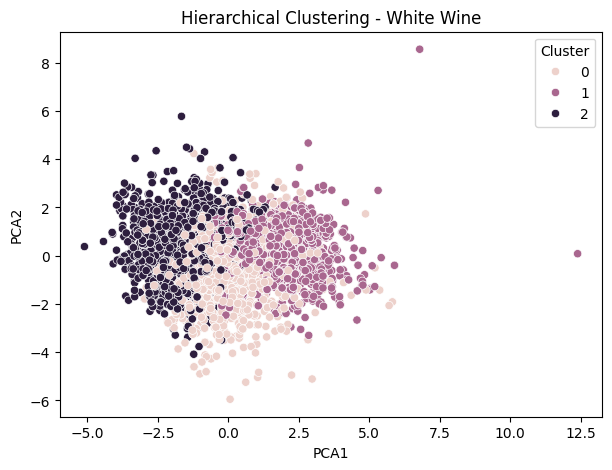

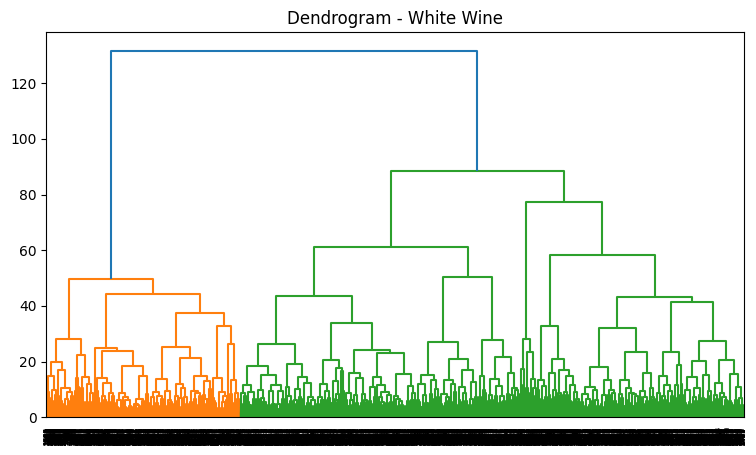

In [12]:
#white wine

pca = PCA(n_components=2)
pca_data = pca.fit_transform(data_scaled)
df_pca = pd.DataFrame(pca_data, columns=["PCA1", "PCA2"])
df_pca["Cluster"] = agglo_labels

plt.figure(figsize=(7,5))
sns.scatterplot(x="PCA1", y="PCA2", hue="Cluster", data=df_pca)
plt.title("Hierarchical Clustering - White Wine")
plt.show()

linked = linkage(data_scaled, method='ward')
plt.figure(figsize=(9,5))
dendrogram(linked)
plt.title("Dendrogram - White Wine")
plt.show()

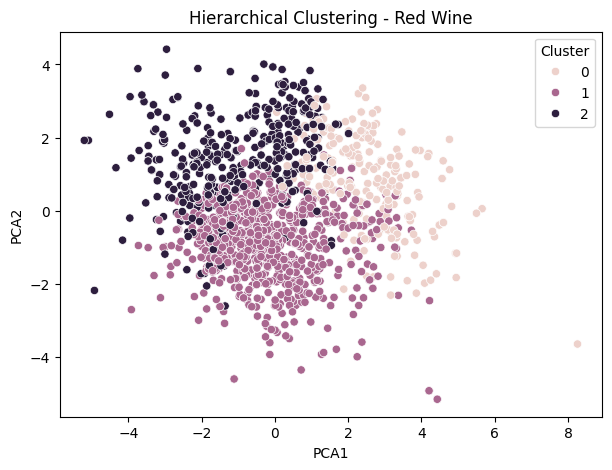

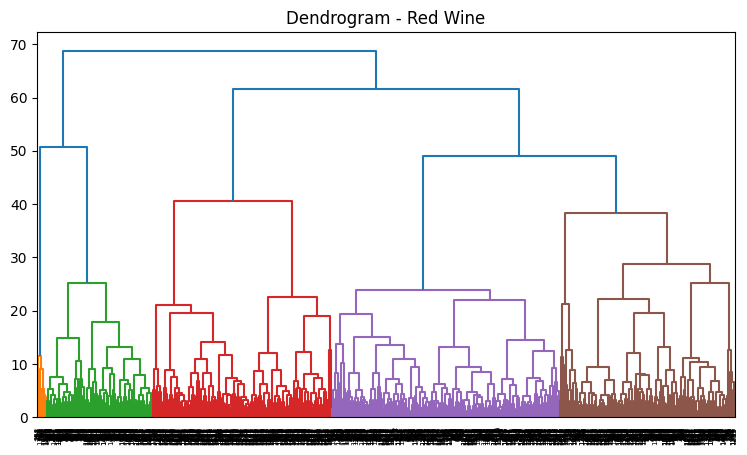

In [13]:
#red wine

pca = PCA(n_components=2)
pca_data_red = pca.fit_transform(data_scaled_red)
df_pca_red = pd.DataFrame(pca_data_red, columns=["PCA1", "PCA2"])
df_pca_red["Cluster"] = agglo_labels_red
plt.figure(figsize=(7,5))

sns.scatterplot(x="PCA1", y="PCA2", hue="Cluster", data=df_pca_red)
plt.title("Hierarchical Clustering - Red Wine")
plt.show()

linked_red = linkage(data_scaled_red, method='ward')
plt.figure(figsize=(9,5))
dendrogram(linked_red)
plt.title("Dendrogram - Red Wine")
plt.show()

In [17]:
df_white["Hierarchical_Cluster"] = agglo_labels
df_red["Hierarchical_Cluster"] = agglo_labels_red

df_white["KMeans_Cluster"] = kmeans_labels
df_red["KMeans_Cluster"] = kmeans_labels_red

df_white.head()
df_red.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,KMeans_Cluster,Hierarchical_Cluster
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0,1
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,0,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,0,1
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,2,1
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0,1


Using PCA to reduce the data to 2 dimensions so it can be plotted easily.
Then we create scatter plots
and then dendrograms are plotted to understand how hierarchical clustering builds clusters step by step and cluster labels from both methods are added back to the datasets.

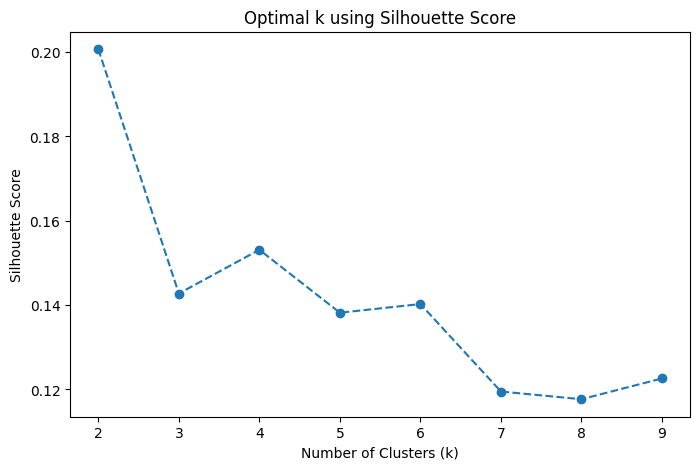

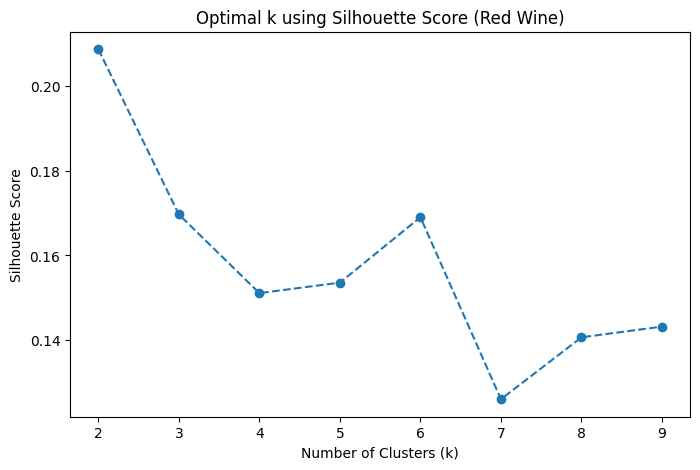

In [19]:
#white wine
silhouette_scores = []
K = range(2, 10)

for k in K:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(data_scaled)
    score = silhouette_score(data_scaled, labels)
    silhouette_scores.append(score)

plt.figure(figsize=(8, 5))
plt.plot(K, silhouette_scores, marker='o', linestyle='--')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Optimal k using Silhouette Score')
plt.show()

#red wine
silhouette_scores_red = []
K = range(2,10)

for k in K:
    km = KMeans(n_clusters=k, random_state=42)
    labels = km.fit_predict(data_scaled_red)
    score = silhouette_score(data_scaled_red, labels)
    silhouette_scores_red.append(silhouette_score(data_scaled_red, labels))

plt.figure(figsize=(8, 5))
plt.plot(K, silhouette_scores_red, marker='o', linestyle='--')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Optimal k using Silhouette Score (Red Wine)')
plt.show()

In this project, clustering was applied to both white and red wine datasets to group similar samples. The data was first scaled to ensure all features were on the same level.

K-Means and Hierarchical clustering were used, and the optimal number of clusters was found using the Elbow Method and Silhouette Score. From the results, k = 2 gave the best clustering for both datasets.

PCA was used to visualize the clusters, which made it easier to understand how the data was grouped. Dendrograms also helped in understanding how clusters were formed step by step.

Overall, both methods worked well, with K-Means being simple and fast, while Hierarchical clustering gave better insight into cluster formation.